# Classification model


In [ ]:
tab = tab[(tab['flags_r'] <= 3 )& (tab['mag_psf_r'] > 13)].drop_duplicates(subset=['id'])

In [ ]:
tab

,Unnamed: 0,id_x,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,...,flags_j0378,flags_j0395,flags_j0410,flags_j0430,flags_j0515,flags_j0660,flags_j0861,flags_r,flags_u,flags_z
6,11,b'i06MC007700QSM',37.204273,-70.742390,14.850342,1.106129,1364.524900,0.992964,0,0,...,2,2,2,2,2,2,2,2,2,2
12,18,b'i06MC007700W87',37.665234,-70.546030,7.107466,1.093844,462.059020,0.000001,0,0,...,0,0,0,0,0,0,0,0,0,0
13,20,b'i06MC007700YB8',37.323734,-70.473015,5.347390,1.065020,474.439200,0.998258,0,0,...,0,0,0,0,0,0,0,0,0,0
15,22,b'i06MC007700ZEO',37.238150,-70.431280,5.590915,1.060642,406.684780,0.996487,0,0,...,2,2,2,2,2,2,2,2,2,2
19,31,b'i06MC013900E66',33.164160,-74.964240,-0.074111,0.967809,-2.753948,0.999999,0,0,...,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42287,65452,b'i06MC00400E5TX',80.537780,-67.809590,NaN,NaN,NaN,0.970139,1,0,...,2,2,2,2,2,2,2,2,2,2
42288,65466,b'i06MC00400EOHG',82.989525,-67.750860,0.276709,0.953619,0.492188,0.842157,0,0,...,2,2,2,2,2,2,2,2,2,2
42289,65472,b'i06MC00400EU55',83.020386,-67.733320,-0.863879,1.029045,-1.298924,0.898416,0,0,...,2,2,2,2,2,2,2,2,2,2
42290,65486,b'i06MC00400EXHC',82.950220,-67.719740,-0.837465,0.956156,-1.747225,0.386522,1,0,...,2,2,2,2,2,2,2,2,2,2


In [ ]:
len(tab)

38620

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pacmap
import hdbscan
import matplotlib.pyplot as plt

# ---- 1) Config ----
BANDS = ['u','J0378','J0395','J0410','J0430','g','J0515','r','J0660','i','J0861','z']
LAMBDA = {'u':3536,'J0378':3770,'J0395':3940,'J0410':4094,'J0430':4292,'g':4751,
          'J0515':5133,'r':6258,'J0660':6614,'i':7690,'J0861':8611,'z':8831}

# ---- 2) Quality cuts ----
def good_row(row):
    req = ['r','i','J0660']  # essencial para Hα
    ok = all(np.isfinite(row[f'mag_psf_{b.lower()}']) for b in req)
    for b in req:
        eb = row.get(f'err_mag_psf_{b.lower()}', np.nan)
        if not np.isfinite(eb) or eb <= 0 or 1.0857/eb < 5:
            return False
    return ok

tab = tab[tab.apply(good_row, axis=1)].copy()

# ---- 3) Cores ----
def col(df, a, b):
    return df[f'mag_psf_{a.lower()}'] - df[f'mag_psf_{b.lower()}']

colors_adj = []
for a, b in zip(BANDS[:-1], BANDS[1:]):
    colors_adj.append(col(tab, a, b).rename(f'{a}-{b}'))

broad = pd.Series(col(tab, 'g', 'r'), name='g-r')
broad2 = pd.Series(col(tab, 'r', 'i'), name='r-i')

# ---- 4) Emission features ----
r = tab['mag_psf_r']; i = tab['mag_psf_i']; j0660 = tab['mag_psf_j0660']
lam_r, lam_i, lam_ha = LAMBDA['r'], LAMBDA['i'], LAMBDA['J0660']
w = (lam_ha - lam_r) / (lam_i - lam_r)
m_cont_ha = r + (i - r) * w
E_Ha = (j0660 - m_cont_ha).rename('E_Halpha_mag')

# Ca II opcional
if all(f'mag_psf_{b.lower()}' in tab.columns for b in ['i','z','J0861']):
    z = tab['mag_psf_z']; j0861 = tab['mag_psf_j0861']
    lam_i, lam_z, lam_cat = LAMBDA['i'], LAMBDA['z'], LAMBDA['J0861']
    w2 = (lam_cat - lam_i) / (lam_z - lam_i)
    m_cont_cat = i + (z - i) * w2
    E_CaT = (j0861 - m_cont_cat).rename('E_CaT_mag')
else:
    E_CaT = None

# ---- 5) Feature matrix ----
feat = pd.concat(colors_adj + [broad, broad2, E_Ha] + ([E_CaT] if E_CaT is not None else []), axis=1)

# ---- 6) Impute + scale ----
X = feat.values
X = SimpleImputer(strategy='median').fit_transform(X)
X = StandardScaler().fit_transform(X)

# ---- 7) PaCMAP ----
mapper = pacmap.PaCMAP(n_components=2, n_neighbors=100, MN_ratio=0.5, FP_ratio=2.0, num_iters=600)
emb = mapper.fit_transform(X)

# ---- 8) Clustering ----
clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
labels = clusterer.fit_predict(emb)



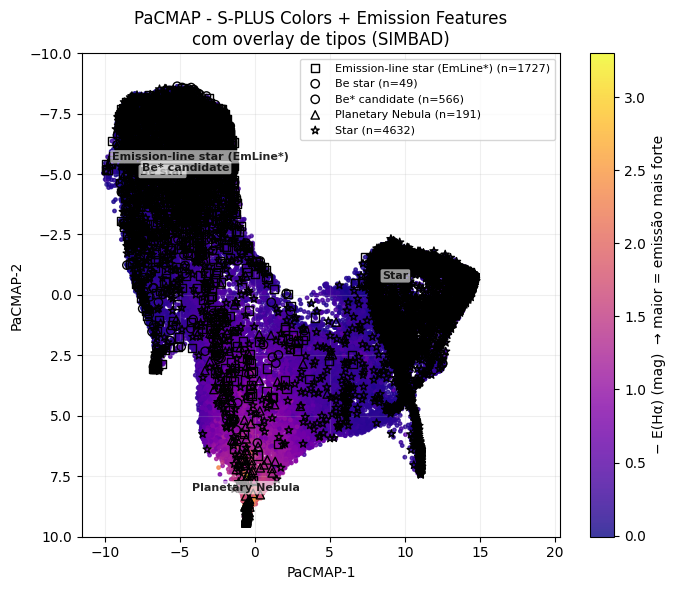

In [ ]:
from collections import OrderedDict

# Alinhar main_type exatamente às linhas usadas no embedding
types = tab.loc[feat.index, 'main_type'].astype(str).fillna('Unknown')

# Mapeamento de categorias -> padrões (regex) + marcador

category_specs = OrderedDict([
    # EMISSION / BE
    ("Emission-line star (EmLine*)", {"pattern": r"(?<!\w)EmLine\*(?!\w)",         "marker": "s"}),
    ("Be star",                      {"pattern": r"(?<!\w)Be\*(?!_Candidate)(?!\w)","marker": "o"}),
    ("Be* candidate",                {"pattern": r"(?<!\w)Be\*_Candidate(?!\w)",    "marker": "o"}),

    # NEBULAE / YSOs / GALAXY
    ("Planetary Nebula",             {"pattern": r"(?<!\w)PlanetaryNeb(?!\w)|\bPN\b","marker": "^"}),
    # ("YSO / T Tauri",                {"pattern": r"(?<!\w)YSO(?!\w)|t\s*tauri",     "marker": "P"}),
    # ("Galaxy",                       {"pattern": r"(?<!\w)Galaxy(?!\w)|galaxies|extragalactic", "marker": "*" }),
    
    # # BINARIES
    # ("Eclipsing binary (EclBin)",    {"pattern": r"(?<!\w)EclBin(?!\w)",            "marker": "v"}),
    # ("Spectroscopic binary (SB*)",   {"pattern": r"(?<!\w)SB\*(?!\w)",              "marker": "<"}),

    # # VARIABLES
    # ("Long-period variable",         {"pattern": r"(?<!\w)LongPeriodV\*(?!\w)",     "marker": ">"}),
    # ("Classical Cepheid",            {"pattern": r"(?<!\w)ClassicalCep(?!\w)",      "marker": "p"}),
    # ("Pulsating variable (PulsV*)",  {"pattern": r"(?<!\w)PulsV\*(?!\w)",           "marker": "D"}),
    # ("RR Lyrae",                     {"pattern": r"(?<!\w)RRLyrae(?!\w)",           "marker": "X"}),

    # # GIANTS / OUTROS
    # ("RGB* candidate",               {"pattern": r"(?<!\w)RGB\*_Candidate(?!\w)",   "marker": "h"}),

    # GENÉRICOS (deixe por último!)
    # ("Variable*",                    {"pattern": r"(?<!\w)Variable\*(?!\w)",        "marker": "d"}),
    ("Star",                         {"pattern": r"(?<!\w)Star(?!\w)",              "marker": "*"}),
])

# Plot base: pontos coloridos por -E_Halpha (maior = emissão mais forte)
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    emb[:, 0], emb[:, 1],
    s=6,
    c=-(feat['E_Halpha_mag'].to_numpy()),
    cmap='plasma',
    alpha=0.8,
    zorder=1
)
cbar = plt.colorbar(sc, label='− E(Hα) (mag)  → maior = emissão mais forte')

# Sobreposição: marcadores para categorias do SIMBAD
legend_handles = []
for label, spec in category_specs.items():
    mask = types.str.contains(spec["pattern"], case=False, regex=True, na=False)
    if not np.any(mask):
        continue
    # Desenhar marcadores vazados para destacar sobre o fundo
    pts = plt.scatter(
        emb[mask, 0], emb[mask, 1],
        s=36,
        facecolors='none',
        edgecolors='k',
        linewidths=1.0,
        marker=spec["marker"],
        zorder=3,
        label=f"{label} (n={int(mask.sum())})"
    )
    legend_handles.append(pts)

    # (Opcional) Anotar centróide do grupo
    x_med, y_med = np.median(emb[mask, 0]), np.median(emb[mask, 1])
    plt.text(x_med, y_med, label, fontsize=8, weight='bold',
             ha='center', va='center', alpha=0.85,
             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
             zorder=4)

plt.title('PaCMAP - S-PLUS Colors + Emission Features\ncom overlay de tipos (SIMBAD)')
plt.xlabel('PaCMAP-1')
plt.ylabel('PaCMAP-2')
plt.ylim(10, -10)
if legend_handles:
    plt.legend(loc='best', fontsize=8, frameon=True)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Contagem por tipo:
main_type
nan                  30350
Star                  4632
EmLine*               1727
EclBin                 860
Be*_Candidate          566
                     ...  
GtowardsCl               1
S*                       1
RadioG                   1
XrayBin_Candidate        1
Pulsar                   1
Name: count, Length: 101, dtype: int64

Positivos (ELS) = 2342 de 42292 (5.54%)

LogisticRegression: PR-AUC=0.316 | ROC-AUC=0.902
Threshold ótimo (F2): 0.731
              precision    recall  f1-score   support

           0      0.982     0.889     0.933      9988
           1      0.275     0.720     0.398       585

    accuracy                          0.880     10573
   macro avg      0.629     0.804     0.666     10573
weighted avg      0.943     0.880     0.904     10573

Matriz de confusão:
 [[8880 1108]
 [ 164  421]]


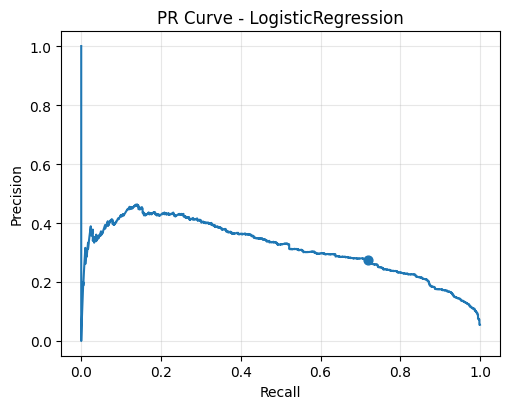


RandomForest: PR-AUC=0.492 | ROC-AUC=0.930
Threshold ótimo (F2): 0.137
              precision    recall  f1-score   support

           0      0.986     0.895     0.939      9988
           1      0.306     0.790     0.441       585

    accuracy                          0.889     10573
   macro avg      0.646     0.842     0.690     10573
weighted avg      0.949     0.889     0.911     10573

Matriz de confusão:
 [[8941 1047]
 [ 123  462]]


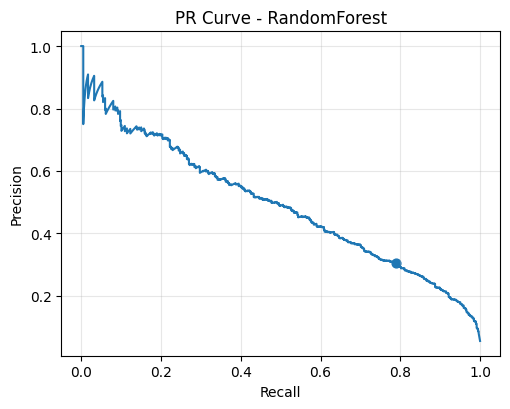


RandomForest (Calibrated): PR-AUC=0.485 | ROC-AUC=0.931
Threshold ótimo (F2): 0.105
              precision    recall  f1-score   support

           0      0.988     0.889     0.936      9988
           1      0.299     0.809     0.437       585

    accuracy                          0.885     10573
   macro avg      0.643     0.849     0.686     10573
weighted avg      0.949     0.885     0.908     10573

Matriz de confusão:
 [[8880 1108]
 [ 112  473]]


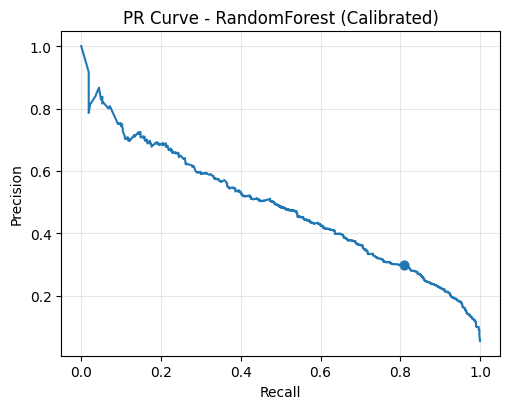

,main_type,y_true,p,y_pred,E_Halpha_mag
17194,EmLine*,1,0.926480,1,-0.462646
18842,EmLine*,1,0.926480,1,-0.330064
25117,EmLine*,1,0.926480,1,-0.368212
20449,EmLine*,1,0.926480,1,-0.331061
5722,EmLine*,1,0.926480,1,-0.458042
24860,EmLine*,1,0.926480,1,-0.370640
24502,EmLine*,1,0.926480,1,-0.392637
24782,EmLine*,1,0.926480,1,-0.294816
24753,EmLine*,1,0.926480,1,-0.343483
20083,EmLine*,1,0.926480,1,-0.351837


In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, f1_score, fbeta_score,
                             classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
import joblib
import matplotlib.pyplot as plt

# ======================
# 1) Features do S-PLUS
# ======================
BANDS = ['u','J0378','J0395','J0410','J0430','g','J0515','r','J0660','i','J0861','z']
LAMBDA = {'u':3536,'J0378':3770,'J0395':3940,'J0410':4094,'J0430':4292,'g':4751,
          'J0515':5133,'r':6258,'J0660':6614,'i':7690,'J0861':8611,'z':8831}

tab = tab.copy()  # seu DataFrame original

# Corte de qualidade mínimo (ajuste às suas colunas/flags)
def good_row(row):
    req = ['r','i','J0660']  # essenciais p/ Hα
    # magnitudes válidas
    if not all(np.isfinite(row.get(f'mag_psf_{b.lower()}', np.nan)) for b in req):
        return False
    # S/N >= 5 (se tiver erros)
    for b in req:
        eb = row.get(f'err_mag_psf_{b.lower()}', np.nan)
        if not np.isfinite(eb) or eb <= 0 or 1.0857/eb < 5:
            return False
    # opcional: flags de saturação, stellarity, etc.
    return True

tab = tab[tab.apply(good_row, axis=1)].reset_index(drop=True)

def col(df, a, b):
    return df[f'mag_psf_{a.lower()}'] - df[f'mag_psf_{b.lower()}']

# Cores adjacentes
feat_cols = {}
for a, b in zip(BANDS[:-1], BANDS[1:]):
    feat_cols[f'{a}-{b}'] = col(tab, a, b)

# Âncoras largas
feat_cols['g-r'] = col(tab,'g','r')
feat_cols['r-i'] = col(tab,'r','i')

# Excessos (Hα e opcional CaT)
r = tab['mag_psf_r']; i = tab['mag_psf_i']; j0660 = tab['mag_psf_j0660']
w  = (LAMBDA['J0660'] - LAMBDA['r']) / (LAMBDA['i'] - LAMBDA['r'])
m_cont_ha = r + (i - r) * w
feat_cols['E_Halpha_mag'] = j0660 - m_cont_ha  # emissão => mais negativo

if all(f'mag_psf_{b.lower()}' in tab.columns for b in ['i','z','J0861']):
    z = tab['mag_psf_z']; j0861 = tab['mag_psf_j0861']
    w2 = (LAMBDA['J0861'] - LAMBDA['i']) / (LAMBDA['z'] - LAMBDA['i'])
    m_cont_cat = i + (z - i) * w2
    feat_cols['E_CaT_mag'] = j0861 - m_cont_cat

# erros (opcional, úteis para ponderar incerteza)
for b in ['g','r','i','J0660']:
    ecol = f'err_mag_psf_{b.lower()}'
    if ecol in tab.columns:
        feat_cols[f'err_{b}'] = tab[ecol]

feat = pd.DataFrame(feat_cols, index=tab.index)

# ==========================
# 2) Rótulos a partir de main_type
# ==========================
# Valores observados:
#   Be*                -> ELS (positivo)
#   Be*_Candidate      -> ELS (positivo "fraco") -> peso menor (opcional)
#   EmLine*            -> ELS (positivo)
#   PlanetaryNeb       -> NEGATIVO (não-estrela; PN)
#
# Você pode escolher um modo mais "estrito" (ignora candidatos) ou "inclusivo".
MODE = "inclusive"   # "strict" ou "inclusive"

mt = tab['main_type'].astype(str).fillna('')

# Positivos "fortes"
is_be        = mt.eq('Be*')
is_emline    = mt.eq('EmLine*')

# Positivos "candidatos"
is_be_cand   = mt.eq('Be*_Candidate')


if MODE == "strict":
    y = (is_be | is_emline).astype(int)     # candidatos ficam como 0
else:  # inclusive
    y = (is_be | is_emline | is_be_cand).astype(int)

print("Contagem por tipo:")
print(mt.value_counts(dropna=False))
print(f"\nPositivos (ELS) = {y.sum()} de {len(y)} ({100*y.mean():.2f}%)")

# (Opcional) Remover classes que você NÃO quer no treinamento
# Ex.: se quiser treinar só "estrelas" vs "não-ELS", mantendo PN como negativo, não remova nada.
# Se quiser evitar viés morfológico, você pode tirar PN do treino (mas mantê-las para teste externo):
# keep = ~is_pn
# y    = y[keep]
# feat = feat.loc[keep]
# tab  = tab.loc[keep]

# (Opcional) Pesos de amostra para candidatos (menos confiança)
sample_weight = np.ones(len(y), dtype=float)
sample_weight[is_be_cand.values] = 0.5   # ajuste 0.5 → 0.7 conforme sua confiança
# ==========================
# 3) Split treino/validação
# ==========================
X_train, X_val, y_train, y_val, idx_tr, idx_va = train_test_split(
    feat, y, np.arange(len(y)), test_size=0.25, random_state=42, stratify=y
)

num_features = list(X_train.columns)

# Pré-processamento (imput + scale)
pre = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc', StandardScaler()),
])

# ==========================
# 4) Modelos
# ==========================
# a) LogReg (interpretável), com balanceamento
logreg = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=None, C=1.0))
])

# b) RandomForest (robusto para não-linearidades), com balanceamento
rf = Pipeline([
    ('pre', pre),
    ('clf', RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        class_weight='balanced_subsample', n_jobs=-1, random_state=42
    ))
])

# Treino
logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

# ==========================
# 5) Calibração de probabilidades
# ==========================
# calibrar o melhor (aqui calibramos o RF; mude se o seu melhor for outro)
rf_cal = CalibratedClassifierCV(rf.named_steps['clf'], method='isotonic', cv=5)
# recalibrar com os dados já pré-processados:
X_train_pp = pre.fit_transform(X_train)
X_val_pp   = pre.transform(X_val)
rf_cal.fit(X_train_pp, y_train)

# ==========================
# 6) Avaliação + threshold ótimo
# ==========================
def evaluate(model, X_tr, y_tr, X_va, y_va, name="model"):
    # obter probs positivas
    if isinstance(model, Pipeline):
        p_val = model.predict_proba(X_va)[:,1]
        p_tr  = model.predict_proba(X_tr)[:,1]
    else:
        # modelo calibrado fora do pipeline (rf_cal)
        p_val = model.predict_proba(pre.transform(X_val))[:,1]
        p_tr  = model.predict_proba(pre.transform(X_tr))[:,1]

    ap = average_precision_score(y_va, p_val)
    roc = roc_auc_score(y_va, p_val)
    print(f"\n{name}: PR-AUC={ap:.3f} | ROC-AUC={roc:.3f}")

    # escolher threshold ótimo por F2 (pesa mais recall)
    prec, rec, thr = precision_recall_curve(y_va, p_val)
    beta = 2.0
    # evitar divisão por zero
    fbeta_vals = (1+beta**2) * (prec*rec) / np.clip(beta**2*prec + rec, 1e-9, None)
    i_opt = int(np.nanargmax(fbeta_vals))
    t_opt = thr[max(i_opt-1, 0)] if i_opt < len(thr) else 0.5

    yhat = (p_val >= t_opt).astype(int)
    print(f"Threshold ótimo (F{beta:.0f}): {t_opt:.3f}")
    print(classification_report(y_va, yhat, digits=3))
    print("Matriz de confusão:\n", confusion_matrix(y_va, yhat))

    # curva PR (rápida)
    plt.figure(figsize=(5.2,4.2))
    plt.plot(rec, prec)
    plt.scatter(rec[i_opt], prec[i_opt], s=40)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"PR Curve - {name}")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    return p_val, t_opt

p_val_log, t_log = evaluate(logreg, X_train, y_train, X_val, y_val, "LogisticRegression")
p_val_rf,  t_rf  = evaluate(rf,    X_train, y_train, X_val, y_val, "RandomForest")
p_val_cal, t_cal = evaluate(rf_cal, X_train, y_train, X_val, y_val, "RandomForest (Calibrated)")

# Escolha final (ex.: calibrado)
best_probs = p_val_cal
best_thr   = t_cal
y_pred     = (best_probs >= best_thr).astype(int)

# Guardar resultados para inspeção
out = tab.iloc[idx_va][['main_type']].copy()
out['id'] = tab.iloc[idx_va]['id'].values
out['y_true'] = y_val.values
out['p']      = best_probs
out['y_pred'] = y_pred
out['E_Halpha_mag'] = X_val['E_Halpha_mag'].values
out.sort_values('p', ascending=False).head(20)

In [ ]:
out

,main_type,y_true,p,y_pred,E_Halpha_mag
20171,Variable*,0,0.702127,1,-0.273315
698,HighPM*,0,0.000253,0,-0.068912
16083,Star,0,0.115063,1,-0.207133
17100,NaN,0,0.107252,1,-0.246077
31268,RRLyrae,0,0.001448,0,-0.224106
...,...,...,...,...,...
27911,NaN,0,0.005486,0,-0.138122
24583,NaN,0,0.006767,0,-0.117004
38747,NaN,0,0.000253,0,-1.070214
9753,SB*,0,0.000253,0,-0.133808
